# 03-POC — Lightweight Proof-of-Concept Modelling
## Malaria Cell Classification Using Deep Learning

**Project:** Malaria Cell Classification Using Deep Learning
**Author:** Kepha | Data Science Capstone Project in Collaboration with Ngao Labs

### Purpose of this notebook
A **cheap, fast** variant of `03_modelling.ipynb`, meant to validate the modelling approach before
committing to the expensive EfficientNetB0 two-phase fine-tuning run. Same splits, same artefacts
from `02_preprocessing.ipynb` — only the model and a few compute knobs change.

### What's different from the full notebook
| | Full notebook | This POC notebook |
|---|---|---|
| Backbone | EfficientNetB0 (~5.3M params) | MobileNetV2, `alpha=0.35` (~0.4M params) |
| Image size | from `preprocessing_config.json` (224×224) | overridden to 96×96 for the POC |
| Training | Phase 1 (frozen) + Phase 2 (fine-tune last 20 layers) | Phase 1 only — no fine-tuning |
| Data | full train/val split | stratified subsample (default 20%) |
| Mixed precision | on when GPU present | unchanged |

This should train in a small fraction of the time of the full pipeline. It's meant to answer
"does this approach work at all" — not to produce a deployable model. Once the POC results look
promising, go back to `03_modelling.ipynb` for the real EfficientNetB0 + fine-tuning run.


In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
# Core libraries
import os
import json
import random
import zipfile

import numpy as np
import pandas as pd

# Baseline model
import joblib
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, roc_auc_score, precision_recall_curve

# Deep learning — lightweight backbone for the POC
import tensorflow as tf
from tensorflow.keras import layers, models, optimizers, callbacks
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input

# Explainability
import matplotlib.pyplot as plt
import matplotlib.cm as cm

print("TensorFlow:", tf.__version__)
GPU_AVAILABLE = bool(tf.config.list_physical_devices("GPU"))
print("GPU available:", GPU_AVAILABLE)


TensorFlow: 2.20.0
GPU available: False


## 1. Load Preprocessing Config & Splits

Still loads `preprocessing_config.json` from `02_preprocessing.ipynb` so the train/val/test splits
and label encoding stay identical to the full pipeline — only `IMG_SIZE` is overridden below for
the POC, and the training data is subsampled.

In [3]:
zip_path = "/content/drive/MyDrive/capstone-project/data/raw/data.zip"
extract_path = "/content/malaria_data"

with zipfile.ZipFile(zip_path, "r") as zip_ref:
    zip_ref.extractall(extract_path)

print("Extraction completed.")

Extraction completed.


In [4]:
PROCESSED_DIR = "/content/drive/MyDrive/capstone-project/data/processed"
MODELS_DIR = "/content/drive/MyDrive/capstone-project/models"
os.makedirs(MODELS_DIR, exist_ok=True)

with open(os.path.join(PROCESSED_DIR, "preprocessing_config.json")) as f:
    config = json.load(f)

RANDOM_SEED = config["random_seed"]
BATCH_SIZE = config["batch_size"]

# --- POC compute knobs -----------------------------------------------------
# Smaller than the full-notebook IMG_SIZE (usually 224x224) — cell morphology is
# still visible at this resolution, and cost scales with pixel count.
IMG_SIZE = (96, 96)
# Fraction of the training/validation split used for the POC. Set to 1.0 to use everything.
POC_SUBSAMPLE_FRAC = 0.2
# -----------------------------------------------------------------------------

random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
tf.random.set_seed(RANDOM_SEED)

# Mixed precision only pays off with a GPU's tensor cores; stay in float32 on CPU.
if GPU_AVAILABLE:
    tf.keras.mixed_precision.set_global_policy("mixed_float16")
print("Compute dtype policy:", tf.keras.mixed_precision.global_policy())

train_df = pd.read_csv(os.path.join(config["split_dir"], "train.csv"))
val_df = pd.read_csv(os.path.join(config["split_dir"], "val.csv"))
test_df = pd.read_csv(os.path.join(config["split_dir"], "test.csv"))

print(f"Full splits    — train: {len(train_df):,} | val: {len(val_df):,} | test: {len(test_df):,}")

if POC_SUBSAMPLE_FRAC < 1.0:
    train_df = (train_df.groupby("label", group_keys=False)
                .apply(lambda g: g.sample(frac=POC_SUBSAMPLE_FRAC, random_state=RANDOM_SEED)))
    val_df = (val_df.groupby("label", group_keys=False)
              .apply(lambda g: g.sample(frac=POC_SUBSAMPLE_FRAC, random_state=RANDOM_SEED)))
    print(f"POC subsample  — train: {len(train_df):,} | val: {len(val_df):,} "
          f"(kept {POC_SUBSAMPLE_FRAC:.0%} of each class, test split untouched)")


Compute dtype policy: <DTypePolicy "float32">
Full splits    — train: 22,046 | val: 2,756 | test: 2,756
POC subsample  — train: 4,410 | val: 552 (kept 20% of each class, test split untouched)


/tmp/ipykernel_683/3484052622.py:36: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: g.sample(frac=POC_SUBSAMPLE_FRAC, random_state=RANDOM_SEED)))
/tmp/ipykernel_683/3484052622.py:38: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: g.sample(frac=POC_SUBSAMPLE_FRAC, random_state=RANDOM_SEED)))


## 2. Baseline — Logistic Regression on HOG + Colour-Histogram Features

Unchanged from the full notebook — this baseline is already cheap (linear model on precomputed
features), so it's kept as-is for a like-for-like comparison point.

In [5]:
baseline_dir = config["baseline_dir"]

X_train = np.load(os.path.join(baseline_dir, "train_features.npy"))
y_train = np.load(os.path.join(baseline_dir, "train_labels.npy"))
X_val = np.load(os.path.join(baseline_dir, "val_features.npy"))
y_val = np.load(os.path.join(baseline_dir, "val_labels.npy"))

print(f"Baseline feature shapes — train: {X_train.shape}, val: {X_val.shape}")

baseline_model = LogisticRegression(
    max_iter=1000,
    class_weight=None,   # dataset is balanced; no reweighting needed
    random_state=RANDOM_SEED,
    n_jobs=-1,
)
baseline_model.fit(X_train, y_train)

val_probs_baseline = baseline_model.predict_proba(X_val)[:, 1]
val_preds_baseline = (val_probs_baseline >= 0.5).astype(int)

print(classification_report(y_val, val_preds_baseline, target_names=["Uninfected", "Parasitized"]))
print(f"Val AUC-ROC: {roc_auc_score(y_val, val_probs_baseline):.4f}")

joblib.dump(baseline_model, os.path.join(MODELS_DIR, "baseline_logreg.joblib"))
print(f"Baseline saved to {os.path.join(MODELS_DIR, 'baseline_logreg.joblib')}")


Baseline feature shapes — train: (22046, 1860), val: (2756, 1860)
              precision    recall  f1-score   support

  Uninfected       0.85      0.86      0.85      1378
 Parasitized       0.86      0.84      0.85      1378

    accuracy                           0.85      2756
   macro avg       0.85      0.85      0.85      2756
weighted avg       0.85      0.85      0.85      2756

Val AUC-ROC: 0.9238
Baseline saved to /content/drive/MyDrive/capstone-project/models/baseline_logreg.joblib


## 3. Rebuild the `tf.data` Pipelines (POC settings)

Same caching strategy as the full notebook (disk-based, `uint8`), just pointed at the smaller
`IMG_SIZE` and the subsampled dataframes from Section 1. Scaling uses `mobilenet_v2.preprocess_input`
to match the new backbone.

In [6]:
import shutil
CACHE_DIR = "/content/drive/MyDrive/capstone-project/data/processed/tfcache_poc"
if os.path.exists(CACHE_DIR):
    shutil.rmtree(CACHE_DIR)
os.makedirs(CACHE_DIR, exist_ok=True)

In [7]:
AUTOTUNE = tf.data.AUTOTUNE
CACHE_DIR = "/content/drive/MyDrive/capstone-project/data/processed/tfcache_poc" if os.path.exists("/content") else "./tfcache_poc"
os.makedirs(CACHE_DIR, exist_ok=True)


def decode_and_resize(filepath, label):
    """Decode + resize only. Kept as uint8 so the on-disk cache stays small."""
    image = tf.io.read_file(filepath)
    image = tf.image.decode_png(image, channels=3)
    image = tf.image.resize(image, IMG_SIZE)
    image = tf.cast(image, tf.uint8)
    return image, label


def apply_mobilenet_scaling(image, label):
    """Cheap per-batch step, applied after caching so the cache doesn't store float32 tensors."""
    image = preprocess_input(tf.cast(image, tf.float32))
    return image, label


def make_dataset(split_df, training, split_name, batch_size=BATCH_SIZE):
    filepaths = split_df["filepath"].to_numpy()
    labels = split_df["label"].to_numpy()

    ds = tf.data.Dataset.from_tensor_slices((filepaths, labels))
    ds = ds.map(decode_and_resize, num_parallel_calls=AUTOTUNE)
    ds = ds.cache(os.path.join(CACHE_DIR, split_name))   # disk-based cache, not in-memory

    if training:
        ds = ds.shuffle(buffer_size=len(split_df), seed=RANDOM_SEED)

    ds = ds.map(apply_mobilenet_scaling, num_parallel_calls=AUTOTUNE)
    ds = ds.batch(batch_size)
    ds = ds.prefetch(AUTOTUNE)
    return ds


train_ds = make_dataset(train_df, training=True, split_name="train")
val_ds = make_dataset(val_df, training=False, split_name="val")
test_ds = make_dataset(test_df, training=False, split_name="test")

augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal_and_vertical", seed=RANDOM_SEED),
    layers.RandomRotation(0.1, seed=RANDOM_SEED),
    layers.RandomContrast(0.1, seed=RANDOM_SEED),
], name="augmentation")


## 4. MobileNetV2 Transfer-Learning Model (POC backbone)

`alpha=0.35` is the smallest standard MobileNetV2 width — roughly 13x fewer parameters than
EfficientNetB0, at the cost of some accuracy headroom. That trade-off is fine for a POC: the goal
here is a fast read on whether transfer learning + this data pipeline works, not the final number.

The backbone stays **frozen** for the whole POC — there is no Phase 2 fine-tuning step in this
notebook (see Section 6).

In [8]:
def build_model(img_size, augmentation_layer, trainable_base=False):
    inputs = layers.Input(shape=(*img_size, 3))
    x = augmentation_layer(inputs)

    base_model = MobileNetV2(include_top=False, weights="imagenet", alpha=0.35, input_tensor=x)
    base_model.trainable = trainable_base

    x = layers.GlobalAveragePooling2D()(base_model.output)
    x = layers.Dropout(0.3)(x)
    # Keep the output layer in float32 even under mixed precision, for numerically stable loss.
    outputs = layers.Dense(1, activation="sigmoid", dtype="float32")(x)

    model = models.Model(inputs, outputs)
    return model, base_model


model, base_model = build_model(IMG_SIZE, augmentation, trainable_base=False)

model.compile(
    optimizer=optimizers.Adam(learning_rate=1e-3),
    loss="binary_crossentropy",
    metrics=[
        tf.keras.metrics.AUC(name="auc"),
        tf.keras.metrics.Recall(name="recall"),
        tf.keras.metrics.Precision(name="precision"),
    ],
)

model.summary()


/tmp/ipykernel_683/1583169714.py:5: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base_model = MobileNetV2(include_top=False, weights="imagenet", alpha=0.35, input_tensor=x)


2019640/2019640 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 96, 96, 3) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ augmentation        │ (None, 96, 96, 3) │          0 │ input_layer[0][0] │
│ (Sequential)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 48, 48,    │        432 │ augmentation[0][… │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 48, 48,    │         64 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 48, 48,    │          0 │ bn_Conv1[0][0]    │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 48, 48,    │        144 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 48, 48,    │         64 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 48, 48,    │          0 │ expanded_conv_de… │
│ (ReLU)              │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 48, 48, 8) │        128 │ expanded_conv_de… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 48, 48, 8) │         32 │ expanded_conv_pr… │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 48, 48,    │        384 │ expanded_conv_pr… │
│ (Conv2D)            │ 48)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 48, 48,    │        192 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 48)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 48, 48,    │          0 │ block_1_expand_B… │
│ (ReLU)              │ 48)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 49, 49,    │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 48)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 24, 24,    │        432 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 48)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 24, 24,    │        192 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 48)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 24, 24,    │          0 │ block_1_depthwis

 Total params: 411,489 (1.57 MB)

 Trainable params: 1,281 (5.00 KB)

 Non-trainable params: 410,208 (1.56 MB)

## 5. Train the Classification Head (Frozen Backbone)

`EarlyStopping` monitors validation AUC and restores the best weights, same as the full notebook.
Checkpoints and history are written under `_poc` filenames so they never collide with (or get
overwritten by) the full pipeline's artefacts.

In [9]:
POC_CKPT = os.path.join(MODELS_DIR, "mobilenetv2_poc.keras")
POC_HISTORY_PATH = os.path.join(MODELS_DIR, "poc_history.csv")

if os.path.exists(POC_CKPT):
    print(f"Found existing POC checkpoint — resuming: {POC_CKPT}")
    model = tf.keras.models.load_model(POC_CKPT)
else:
    print("No POC checkpoint found — starting from scratch.")
    # `model` was already built and compiled in the previous cell

EPOCHS_POC = 8  # a POC run — enough to see if the approach has legs, not a full training schedule

poc_callbacks = [
    callbacks.EarlyStopping(monitor="val_auc", mode="max", patience=3, restore_best_weights=True),
    callbacks.ModelCheckpoint(POC_CKPT, monitor="val_auc", mode="max", save_best_only=True),
    callbacks.ReduceLROnPlateau(monitor="val_auc", mode="max", factor=0.5, patience=2, min_lr=1e-6),
]

history_poc = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS_POC,
    callbacks=poc_callbacks,
)

new_rows = pd.DataFrame(history_poc.history)
new_rows.to_csv(POC_HISTORY_PATH, mode="a", header=not os.path.exists(POC_HISTORY_PATH), index=False)
print(f"POC history appended to {POC_HISTORY_PATH}")


Found existing POC checkpoint — resuming: /content/drive/MyDrive/capstone-project/models/mobilenetv2_poc.keras
Epoch 1/8
138/138 ━━━━━━━━━━━━━━━━━━━━ 40s 237ms/step - auc: 0.9519 - loss: 0.2826 - precision: 0.8816 - recall: 0.8748 - val_auc: 0.9635 - val_loss: 0.4622 - val_precision: 0.9884 - val_recall: 0.6159 - learning_rate: 0.0010
Epoch 2/8
138/138 ━━━━━━━━━━━━━━━━━━━━ 34s 207ms/step - auc: 0.9445 - loss: 0.3049 - precision: 0.8720 - recall: 0.8649 - val_auc: 0.9581 - val_loss: 0.5793 - val_precision: 0.9937 - val_recall: 0.5761 - learning_rate: 0.0010
Epoch 3/8
138/138 ━━━━━━━━━━━━━━━━━━━━ 41s 206ms/step - auc: 0.9459 - loss: 0.2981 - precision: 0.8729 - recall: 0.8567 - val_auc: 0.9606 - val_loss: 0.5209 - val_precision: 0.9882 - val_recall: 0.6087 - learning_rate: 0.0010
Epoch 4/8
138/138 ━━━━━━━━━━━━━━━━━━━━ 28s 204ms/step - auc: 0.9471 - loss: 0.2964 - precision: 0.8871 - recall: 0.8662 - val_auc: 0.9610 - val_loss: 0.4432 - val_precision: 0.9886 - val_recall: 0.6304 - learnin

## 6. No Fine-Tuning Phase (By Design)

The full notebook's Phase 2 — unfreezing and fine-tuning the last 20 backbone layers at a 100x
lower learning rate — is the single most expensive step in the pipeline, and it exists to squeeze
out the last few points of accuracy once the overall approach is already validated. It's
deliberately **skipped here**.

If this POC's head-only results look promising, the next step is not to add fine-tuning to this
notebook — it's to go back to `03_modelling.ipynb` and run the full EfficientNetB0 pipeline at full
resolution and full data volume, since that's the version intended for production.

## 7. Training Curves

Reads the **persisted** history CSV rather than the in-memory `history_poc` object, matching the
resumable pattern from the full notebook.

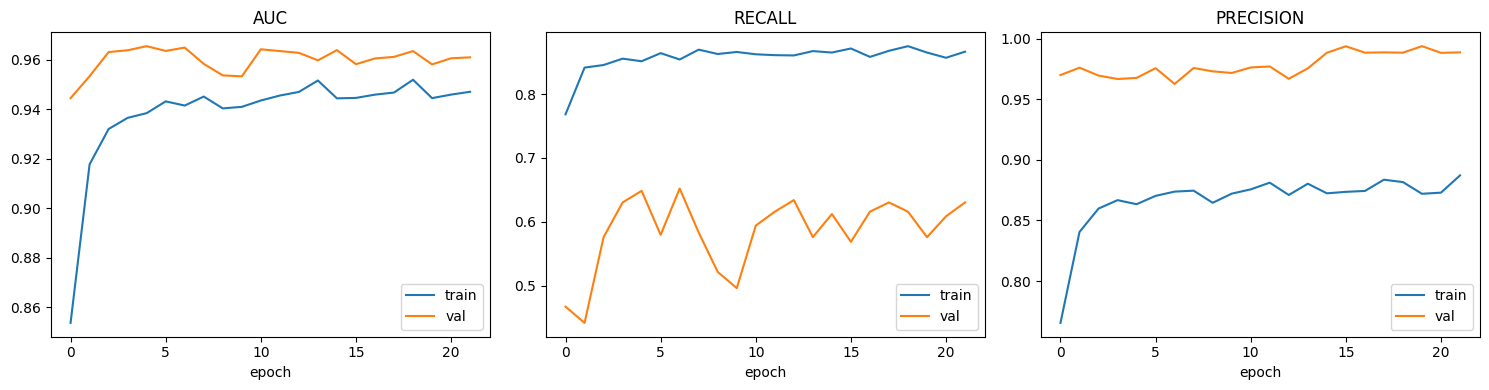

In [10]:
poc_history_df = pd.read_csv(POC_HISTORY_PATH)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, metric in zip(axes, ["auc", "recall", "precision"]):
    ax.plot(poc_history_df[metric], label="train")
    ax.plot(poc_history_df[f"val_{metric}"], label="val")
    ax.set_title(metric.upper())
    ax.set_xlabel("epoch")
    ax.legend()
plt.tight_layout()
plt.show()


## 8. Decision Threshold Tuning

Same logic as the full notebook: sweep thresholds against validation predictions and pick the
**highest threshold that still achieves ≥97% recall** on the parasitized class. Treat this POC
threshold as directional — it's tuned on a subsampled validation set with a much weaker backbone,
not the number to ship.

In [11]:
val_probs = model.predict(val_ds).ravel()
val_labels = val_df["label"].to_numpy()

precision, recall, thresholds = precision_recall_curve(val_labels, val_probs)

TARGET_RECALL = 0.97
valid = recall[:-1] >= TARGET_RECALL
if valid.any():
    best_idx = np.where(valid)[0][np.argmax(precision[:-1][valid])]
    decision_threshold = float(thresholds[best_idx])
else:
    decision_threshold = 0.5
    print(f"No threshold reached {TARGET_RECALL:.0%} recall on validation data — defaulting to 0.5.")

val_preds = (val_probs >= decision_threshold).astype(int)
print(f"Chosen decision threshold: {decision_threshold:.4f}")
print(classification_report(val_labels, val_preds, target_names=["Uninfected", "Parasitized"]))

with open(os.path.join(MODELS_DIR, "poc_decision_threshold.json"), "w") as f:
    json.dump({
        "decision_threshold": decision_threshold,
        "target_recall": TARGET_RECALL,
        "val_auc": float(roc_auc_score(val_labels, val_probs)),
    }, f, indent=2)


18/18 ━━━━━━━━━━━━━━━━━━━━ 4s 163ms/step
Chosen decision threshold: 0.0142
              precision    recall  f1-score   support

  Uninfected       0.96      0.73      0.83       276
 Parasitized       0.78      0.97      0.87       276

    accuracy                           0.85       552
   macro avg       0.87      0.85      0.85       552
weighted avg       0.87      0.85      0.85       552



## 9. Grad-CAM Explainability

Same technique as the full notebook, pointed at MobileNetV2's last conv activation (`out_relu`)
instead of EfficientNetB0's `top_conv`.

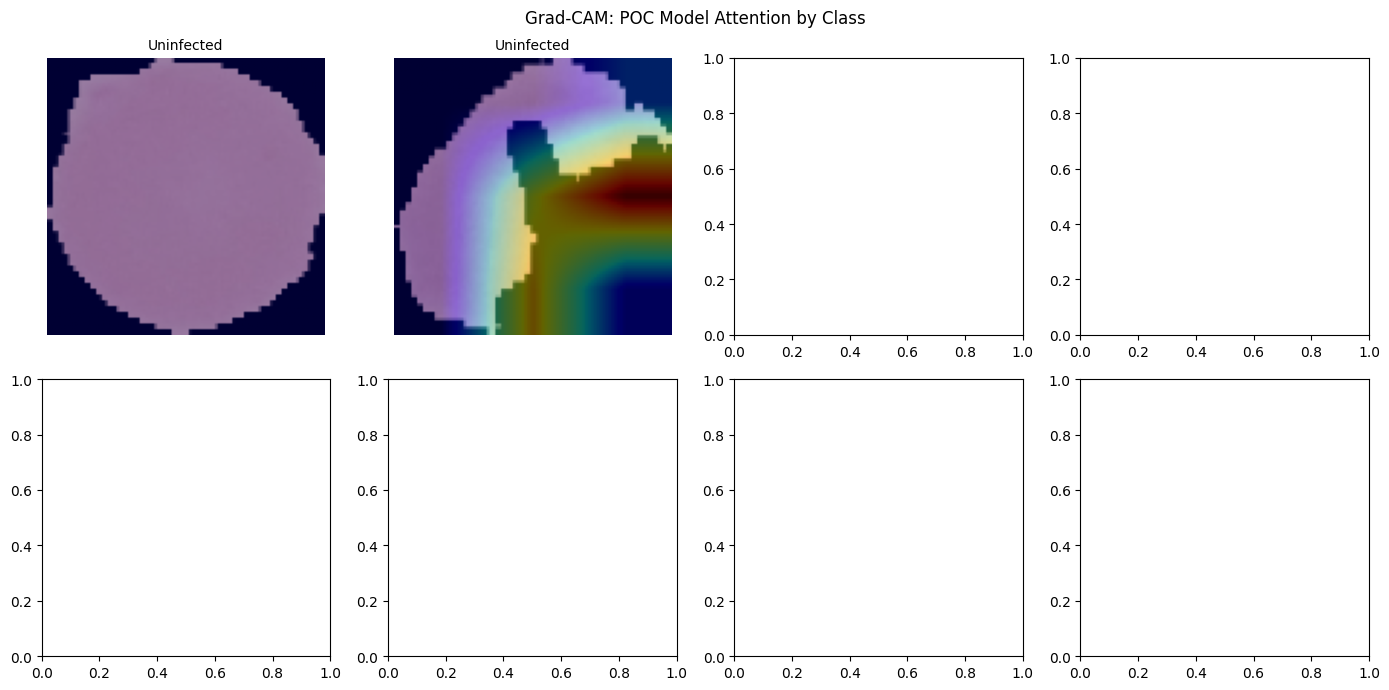

In [12]:
LAST_CONV_LAYER = "out_relu"  # MobileNetV2's last conv activation (EfficientNetB0 used "top_conv")


def make_gradcam_heatmap(img_array, model, last_conv_layer_name):
    grad_model = tf.keras.models.Model(
        model.inputs, [model.get_layer(last_conv_layer_name).output, model.output]
    )
    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(img_array)
        loss = predictions[:, 0]

    grads = tape.gradient(loss, conv_outputs)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

    conv_outputs = conv_outputs[0]
    heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)
    heatmap = tf.maximum(heatmap, 0) / (tf.math.reduce_max(heatmap) + 1e-8)
    return heatmap.numpy()


def overlay_gradcam(image, heatmap, alpha=0.4):
    heatmap_resized = tf.image.resize(heatmap[..., tf.newaxis], IMG_SIZE).numpy().squeeze()
    heatmap_colored = cm.jet(heatmap_resized)[..., :3]

    display_img = (image - image.min()) / (image.max() - image.min() + 1e-8)
    overlaid = display_img * (1 - alpha) + heatmap_colored * alpha
    return overlaid


# Pull a few examples from each class for a qualitative check
fig, axes = plt.subplots(2, 4, figsize=(14, 7))
for images, labels in val_ds.take(1):
    for cls, label_value in [("Uninfected", 0), ("Parasitized", 1)]:
        idxs = np.where(labels.numpy() == label_value)[0][:2]
        for col, i in enumerate(idxs):
            img_array = tf.expand_dims(images[i], axis=0)
            heatmap = make_gradcam_heatmap(img_array, model, LAST_CONV_LAYER)
            overlaid = overlay_gradcam(images[i].numpy(), heatmap)

            row = 0 if label_value == 0 else 1
            axes[row, col].imshow(overlaid)
            axes[row, col].set_title(cls, fontsize=10)
            axes[row, col].axis("off")
    break

plt.suptitle("Grad-CAM: POC Model Attention by Class")
plt.tight_layout()
plt.show()


## 10. Summary & Next Steps

**Artefacts written to `models/`:**
- `baseline_logreg.joblib` — fitted Logistic Regression baseline (shared with the full notebook)
- `mobilenetv2_poc.keras` — best head-only POC checkpoint
- `poc_history.csv` — per-epoch metrics for the POC run
- `poc_decision_threshold.json` — POC decision threshold + validation metrics

**How to read this POC:**
- If validation AUC/recall look reasonable here, the overall approach (splits, augmentation,
  transfer learning, threshold tuning) is likely sound — proceed to `03_modelling.ipynb` for the
  full EfficientNetB0 + fine-tuning run at full resolution and full data volume.
- If results are poor even accounting for the smaller backbone/image size/data fraction, that's
  worth investigating now — e.g. by inspecting the Grad-CAM overlays above — before spending compute
  on the expensive run.
- This POC's checkpoint and threshold are **not** intended to be carried forward into
  `04_evaluation.ipynb` — only the full notebook's `efficientnetb0_final.keras` and
  `decision_threshold.json` are the production artefacts.
